# Synthetic Counterfactual + Undermatching Demo

This notebook reproduces the main figures of the paper using synthetic data.
Program admissions policies reflect actual admissions policies of programs, using the high school directory (`fall_2022.xlsx`). The notebook samples a subset of these programs for efficiency. All student data is generated randomly.

Students are assumed to rank programs based on a noisy scoring that combines transit distance and school graduation rate. The weight of these two components can be altered in the parameters. Students from different ethnicities are synthetically set to have different noise parameters (which could reflect lack of information or idiosyncratic preferences). More noise generally means that students apply to more safety programs.

In [163]:
import numpy as np
import pandas as pd

from collections import defaultdict
from create_counterfactuals_export import create_counterfactual_df
from create_counterfactual_with_scores_export import get_seatgroup_scores
import deferred_acceptance as da

## Global Parameters

These are the main parameters guiding the generation of synthetic data.

In [ ]:
# Core simulation parameters
RANDOM_SEED = 42
N_PROGRAMS = 75
N_STUDENTS = 6000
TOTAL_SEATS_PER_PROGRAM = 100

# Weights that determine synthetic portfolio formation.
TRANSIT_WEIGHT = 1.0
GRAD_RATE_WEIGHT = 2.0

# Group-specific noise levels for synthetic portfolio formation. These default parameters reflect the qualitative findings in the paper (that Asian and white students apply to more reach programs).
GROUP_NOISE_SD = {
    'asian': 0.1,
    'black': 1.0,
    'hispanic': 1.0,
    'white': 0.1,
}

# Recommendation selection parameter (R=1 chooses the best recommendation, R=2 randomly chooses between the two best, etc.)
RECOMMENDATION_TOP_R = 1

# Transit constraint used for counterfactual match eligibility
COUNTERFACTUAL_MAX_COMMUTE_MINUTES = 33

print('Global parameters loaded.')
print({
    'RANDOM_SEED': RANDOM_SEED,
    'N_PROGRAMS': N_PROGRAMS,
    'N_STUDENTS': N_STUDENTS,
    'TOTAL_SEATS_PER_PROGRAM': TOTAL_SEATS_PER_PROGRAM,
    'TRANSIT_WEIGHT': TRANSIT_WEIGHT,
    'GRAD_RATE_WEIGHT': GRAD_RATE_WEIGHT,
    'GROUP_NOISE_SD': GROUP_NOISE_SD,
    'RECOMMENDATION_TOP_R': RECOMMENDATION_TOP_R,
    'COUNTERFACTUAL_MAX_COMMUTE_MINUTES': COUNTERFACTUAL_MAX_COMMUTE_MINUTES,
})

Global parameters loaded.
{'RANDOM_SEED': 42, 'N_PROGRAMS': 75, 'N_STUDENTS': 6000, 'TOTAL_SEATS_PER_PROGRAM': 100, 'TRANSIT_WEIGHT': 1.0, 'GRAD_RATE_WEIGHT': 2.0, 'GROUP_NOISE_SD': {'asian': 0.1, 'black': 1.0, 'hispanic': 1.0, 'white': 0.1}, 'RECOMMENDATION_TOP_R': 1, 'COUNTERFACTUAL_MAX_COMMUTE_MINUTES': 33}


## 1) Build `df_programs` from `fall_2022.xlsx`


In [146]:
def add_offer_rates_local(df_programs, df_students):
    """Local copy of offer-rate logic from create_program_df_export.add_offer_rates."""
    offer_reject_dict = defaultdict(lambda: {'offers': [], 'rejects': []})
    for index, row in df_students.iterrows():
        if pd.notnull(row['matched_choice_num']):
            matched_choice_num = int(row['matched_choice_num'])
        else:
            matched_choice_num = 13

        for i in range(1, matched_choice_num):
            rejected_program = row[f'programcode{i}']
            offer_reject_dict[rejected_program]['rejects'].append(index)
        if matched_choice_num < 13:
            offered_program = row[f'programcode{matched_choice_num}']
            offer_reject_dict[offered_program]['offers'].append(index)

    offer_rate_dict = defaultdict(lambda: 1.0)
    for programcode in offer_reject_dict.keys():
        num_offers = len(offer_reject_dict[programcode]['offers'])
        num_rejects = len(offer_reject_dict[programcode]['rejects'])
        if num_offers + num_rejects > 0:
            offer_rate_dict[programcode] = num_offers / (num_offers + num_rejects)

    df_programs = df_programs.copy()
    df_programs['offer_rate'] = df_programs['programcode'].apply(lambda x: offer_rate_dict[x])
    return df_programs

In [ ]:
import re
import json

directory_path = 'fall_2022.xlsx'
df_dir = pd.read_excel(directory_path, sheet_name='Data')

# ZIP->ZIP transit time matrix (minutes)
with open('zipcode_transit_distances.json', 'r') as f:
    transit_matrix = json.load(f)
available_zips = sorted(transit_matrix.keys())

def extract_grade_weight(text):
    if 'Average Course Grades' in str(text):
        match = re.search(r'(\d+)%', str(text))
        if match:
            return int(match.group(1)) / 100
    return 0.0

def extract_dia_fraction(text):
    match = re.search(r'(\d+)%', str(text))
    if match:
        return int(match.group(1)) / 100
    return 0.0

rows = []
for _, school in df_dir.iterrows():
    for i in range(1, 13):
        code_col = f'code{i}'
        code = school.get(code_col, np.nan)
        if pd.isna(code) or str(code).strip() in {'', 'NO CODE', 'nan'}:
            continue

        requirements = [school.get(f'requirement_{j}_{i}', np.nan) for j in range(1, 5)]
        method = school.get(f'method{i}', np.nan)
        eligibility = school.get(f'eligibility{i}', np.nan)
        audition_info = school.get(f'auditioninformation{i}', np.nan)
        priorities = [school.get(f'admissionspriority{j}{i}', np.nan) for j in range(1, 4)]
        dia_details = school.get('diadetails', np.nan)

        rows.append({
            'programcode': str(code).strip(),
            'dbn': school.get('dbn', np.nan),
            'program_zip_raw': school.get('zip', np.nan),
            'graduation_rate_raw': school.get('graduation_rate', np.nan),
            'requirements': requirements,
            'method': method,
            'eligibility': eligibility,
            'audition_info': audition_info,
            'priorities': priorities,
            'grade_weight': extract_grade_weight(requirements[0]),
            'dia_details': dia_details,
            'dia_fraction': extract_dia_fraction(dia_details),
        })

df_programs_full = pd.DataFrame(rows).drop_duplicates(subset=['programcode']).reset_index(drop=True)

# Use the same inclusion criteria as create_counterfactual_df:
# Open OR Ed. Opt. OR pure Screened (grade_weight == 1)
df_programs = df_programs_full[
    (df_programs_full['method'].isin({'Open', 'Ed. Opt.'}))
    | ((df_programs_full['method'] == 'Screened') & (df_programs_full['grade_weight'] == 1.0))
].copy()

# Reproducible subset of programs
if len(df_programs) > N_PROGRAMS:
    df_programs = df_programs.sample(n=N_PROGRAMS, random_state=RANDOM_SEED).reset_index(drop=True)

# Clean program ZIPs and ensure they are in the transit matrix domain
def clean_zip(z):
    s = ''.join(ch for ch in str(z) if ch.isdigit())
    if len(s) >= 5:
        return s[:5]
    if len(s) > 0:
        return s.zfill(5)
    return np.nan

df_programs['program_zip'] = df_programs['program_zip_raw'].apply(clean_zip)
missing_mask = ~df_programs['program_zip'].isin(available_zips)
df_programs.loc[missing_mask, 'program_zip'] = rng.choice(available_zips, size=missing_mask.sum(), replace=True)

# Add school graduation rate (cleaned from directory values)
df_programs['graduation_rate'] = pd.to_numeric(df_programs['graduation_rate_raw'], errors='coerce')
if df_programs['graduation_rate'].notna().any():
    df_programs['graduation_rate'] = df_programs['graduation_rate'].fillna(df_programs['graduation_rate'].median())
else:
    df_programs['graduation_rate'] = 75.0


df_programs['offer_rate'] = np.nan

print('Programs extracted from directory:', len(df_programs_full))
print('Programs used in demo:', len(df_programs))
df_programs[['programcode', 'dbn', 'program_zip', 'graduation_rate', 'method']].head(12)


Programs extracted from directory: 952
Programs used in demo: 75


,programcode,dbn,program_zip,graduation_rate,method,performance
0,Q29J,30Q450,11106,83,Screened,-0.073490
1,K64A,17K546,11203,95,Screened,-1.259587
2,Q01A,30Q301,11101,98,Ed. Opt.,-1.526608
3,K68J,19K660,11207,80,Ed. Opt.,-0.343522
4,K78C,13K419,11201,100,Screened,-1.285770
5,M30B,06M463,10040,80,Ed. Opt.,0.017941
6,L41A,18K576,11236,91,Open,0.635228
7,X35B,11X418,10462,79,Ed. Opt.,-0.609862
8,R10D,31R445,10302,75,Ed. Opt.,-0.425152
9,Y27A,09X327,10452,86,Open,0.113360


## 2) Generate applications from transit-based scores (+ noise), then derive matches with deferred acceptance


In [ ]:
program_codes_all = df_programs["programcode"].to_list()
boroughs = ["M", "K", "Q", "X", "R"]
ethnicities = ["asian", "black", "hispanic", "white"]
edopt_groups = ["HIGH", "MIDDLE", "LOW"]

# Pull key behavioral parameters from the global parameters
group_noise_sd = GROUP_NOISE_SD.copy()
transit_weight = TRANSIT_WEIGHT
grad_rate_weight = GRAD_RATE_WEIGHT

print("Noise SD by ethnicity:", group_noise_sd)
print("Utility weights:", {"transit_weight": transit_weight, "grad_rate_weight": grad_rate_weight})

program_zip_dict = dict(zip(df_programs["programcode"], df_programs["program_zip"]))
grad_rate_dict = dict(zip(df_programs["programcode"], df_programs["graduation_rate"]))

def random_tiebreaker():
    return "".join(rng.choice(list("0123456789abcdef"), size=8))

def transit_score(student_zip, program_code):
    # Lower commute time is better
    program_zip = program_zip_dict[program_code]
    minutes = transit_matrix.get(student_zip, {}).get(program_zip, 90)
    return -float(minutes)

def grad_rate_score(program_code):
    # Higher graduation rate is better
    return float(grad_rate_dict[program_code])

def choose_portfolio_by_utility(student_zip, program_pool, k=12, noise_sd=1.0, w_transit=TRANSIT_WEIGHT, w_grad=GRAD_RATE_WEIGHT):
    utilities = []
    for p in program_pool:
        transit_component = transit_score(student_zip, p) / 60.0
        grad_component = grad_rate_score(p) / 100.0
        base = w_transit * transit_component + w_grad * grad_component
        noisy_utility = base + float(rng.normal(0, noise_sd))
        utilities.append((p, noisy_utility))

    # Portfolio rank is explicitly the descending order of realized noisy utility.
    ranked_pairs = sorted(utilities, key=lambda x: x[1], reverse=True)[:k]
    ranked_programs = [p for p, _ in ranked_pairs]
    ranked_scores = [s for _, s in ranked_pairs]
    return ranked_programs, ranked_scores

# 1) Create students and set portfolios using transit + graduation-rate score + noise
rows = []

for i in range(N_STUDENTS):
    student_zip = rng.choice(available_zips)
    student_ethnicity = rng.choice(ethnicities)
    noise_sd = group_noise_sd[student_ethnicity]
    ranked_programs, ranked_scores = choose_portfolio_by_utility(
        student_zip,
        program_codes_all,
        k=12,
        noise_sd=noise_sd,
        w_transit=transit_weight,
        w_grad=grad_rate_weight,
    )

    row = {
        "student_id_scram": f"S{i:05d}",
        "zipcode": student_zip,
        "tiebreaker": random_tiebreaker(),
        "currentschooldbn": f"0{rng.integers(1, 10)}{rng.choice(boroughs)}{rng.integers(100, 999)}",
        "avg_grades_for_tier": float(rng.normal(250, 60)),
        "resborough": rng.choice(boroughs),
        "edoptcategory": rng.choice(edopt_groups),
        "poverty": int(rng.random() < 0.55),
        "ethnicity": student_ethnicity,
    }
    for rank in range(1, 13):
        row[f"programcode{rank}"] = ranked_programs[rank - 1]
        row[f"portfolio_noisy_score{rank}"] = ranked_scores[rank - 1]
    rows.append(row)

df_students = pd.DataFrame(rows)

# Normalize to plain Python string dtype to avoid pandas StringArray logical-op issues
for col in ["resborough", "currentschooldbn", "edoptcategory", "tiebreaker", "ethnicity"]:
    df_students[col] = df_students[col].astype(str)

# 2) Build admissions scores by seatgroup (uses project scoring logic)
df_scores, seat_group_fractions_dict, programs_for_da = get_seatgroup_scores(df_students.copy(), df_programs.copy())

# Keep only programs that have score definitions (Screened grade-only, Ed. Opt., Open)
programs_for_da = [p for p in programs_for_da if p in set(program_codes_all)]

# 3) Prepare deferred acceptance inputs
student_index = {sid: idx for idx, sid in enumerate(df_students["student_id_scram"].to_list())}
seatgroups = df_scores.columns.to_list()
seatgroup_index = {sg: idx for idx, sg in enumerate(seatgroups)}

program_to_seatgroups = defaultdict(list)
for sg in seatgroups:
    p = sg.split("-")[0]
    program_to_seatgroups[p].append(sg)

# Student preferences over seatgroups: expand each listed program into its seatgroups
student_prefs = []
for _, row in df_students.iterrows():
    prefs = []
    for i in range(1, 13):
        prog = row[f"programcode{i}"]
        if pd.notnull(prog) and prog in program_to_seatgroups:
            prefs.extend([seatgroup_index[sg] for sg in program_to_seatgroups[prog]])
    seen = set()
    deduped = []
    for c in prefs:
        if c not in seen:
            deduped.append(c)
            seen.add(c)
    student_prefs.append(deduped)

# College (seatgroup) preferences from descending scores
college_prefs = []
for sg in seatgroups:
    col = df_scores[sg].to_numpy()
    college_prefs.append(np.argsort(-col).tolist())

# Capacities by seatgroup (program total seats split by seat-group fractions)
program_caps = {p: TOTAL_SEATS_PER_PROGRAM for p in programs_for_da}
college_caps = []
for sg in seatgroups:
    p, g = sg.split("-")
    g = int(g)
    fracs = seat_group_fractions_dict[p]
    base = [int(np.floor(program_caps[p] * f)) for f in fracs]
    remainder = program_caps[p] - sum(base)
    order = np.argsort([program_caps[p] * f - np.floor(program_caps[p] * f) for f in fracs])[::-1]
    for idx in order[:remainder]:
        base[idx] += 1
    college_caps.append(base[g])

# 4) Run student-proposing deferred acceptance
student_matches, college_matches = da.get_match(student_prefs, college_prefs, college_caps)

# 5) Map seatgroup match back to matched program and matched rank in original portfolio
matched_seatgroup = []
matched_program = []
matched_choice_num = []
for i, c in enumerate(student_matches):
    if c == -1:
        matched_seatgroup.append(np.nan)
        matched_program.append(np.nan)
        matched_choice_num.append(np.nan)
        continue
    sg = seatgroups[c]
    prog = sg.split("-")[0]
    matched_seatgroup.append(sg)
    matched_program.append(prog)
    rank = np.nan
    for r in range(1, 13):
        if df_students.iloc[i][f"programcode{r}"] == prog:
            rank = r
            break
    matched_choice_num.append(rank)

df_students["matched_program"] = matched_program
df_students["matched_choice_num"] = matched_choice_num
df_students["matched"] = df_students["matched_program"].notna().astype(int)
df_students["matched_seatgroup"] = matched_seatgroup

print("Students:", len(df_students))
print("Programs in DA simulation:", len(programs_for_da))
print("Seatgroups in DA simulation:", len(seatgroups))
print("Match rate:", round(df_students["matched"].mean(), 3))
df_students[["student_id_scram", "matched", "matched_program", "matched_choice_num", "matched_seatgroup"]].head(10)


Noise SD by ethnicity: {'asian': 0.1, 'black': 1.0, 'hispanic': 1.0, 'white': 0.1}
Utility weights: {'transit_weight': 1.0, 'grad_rate_weight': 2.0}
Portfolios ordered by noisy scores: True


/Users/kennypeng/Downloads/undermatching_nature_cities-main/create_counterfactual_with_scores_export.py:214: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  students_df[f'{programcode}-{i}'] = scores[i]
/Users/kennypeng/Downloads/undermatching_nature_cities-main/create_counterfactual_with_scores_export.py:214: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  students_df[f'{programcode}-{i}'] = scores[i]
/Users/kennypeng/Downloads/undermatching_nature_cities-main/create_counterfactual_with_scores_export.py:214: PerformanceWarning: Dat

102
Students: 6000
Programs in DA simulation: 75
Seatgroups in DA simulation: 165
Match rate: 0.981


,student_id_scram,matched,matched_program,matched_choice_num,matched_seatgroup
0,S00000,1,Y32B,1.0,Y32B-1
1,S00001,1,M86A,1.0,M86A-0
2,S00002,1,M17J,1.0,M17J-0
3,S00003,1,X29K,1.0,X29K-0
4,S00004,1,K54A,2.0,K54A-0
5,S00005,1,X83X,1.0,X83X-2
6,S00006,1,K64A,1.0,K64A-0
7,S00007,1,R30S,1.0,R30S-0
8,S00008,1,M30B,1.0,M30B-0
9,S00009,1,M35C,2.0,M35C-0


## 3) Compute empirical offer rates from synthetic matches

This uses `add_offer_rates` from `create_program_df_export.py`.

In [149]:
df_programs = add_offer_rates_local(df_programs.copy(), df_students.copy())

# Number of students listing each program anywhere in their 12-choice portfolio
portfolio_cols = [f"programcode{i}" for i in range(1, 13)]
listed_counts = (
    df_students[portfolio_cols]
    .melt(value_name="programcode")
    .dropna(subset=["programcode"])
    .groupby("programcode")
    .size()
    .rename("num_students_listed")
)

df_programs = df_programs.merge(listed_counts, on="programcode", how="left")
df_programs["num_students_listed"] = df_programs["num_students_listed"].fillna(0).astype(int)

df_programs[["programcode", "offer_rate", "num_students_listed"]].sort_values("offer_rate")

,programcode,offer_rate,num_students_listed
46,M64A,0.170940,3158
69,M94A,0.180505,2944
71,K78A,0.181159,2443
16,K78B,0.183824,2444
4,K78C,0.185874,2435
...,...,...,...
48,K16I,1.000000,351
66,K56C,1.000000,487
68,R17F,1.000000,294
72,R19E,1.000000,266


## 4) Compute counterfactual offers

In [150]:
df_students_cf_input = df_students.copy()

# Robust dtype guard for pandas>=3: force plain Python-string object dtype
for col in ["resborough", "currentschooldbn", "edoptcategory", "tiebreaker", "ethnicity"]:
    df_students_cf_input[col] = df_students_cf_input[col].fillna("").map(str).astype("object")

df_counterfactuals, programs_counterfactual = create_counterfactual_df(
    df_students_cf_input,
    df_programs.copy(),
)

print("Programs included in counterfactual simulation:", len(programs_counterfactual))
print(programs_counterfactual[:10])
df_counterfactuals.head()

Computing counterfactuals for 75 programs:
19 pure screened programs
42 Ed Opt. programs
14 Open programs
Programs included in counterfactual simulation: 75
['M91A', 'K65A', 'R10E', 'K60J', 'M70A', 'M22X', 'M37X', 'L41A', 'M17J', 'M86A']


,M91A,K65A,R10E,K60J,M70A,M22X,M37X,L41A,M17J,M86A,...,M75A,R10R,Q50H,K60N,K78D,K54B,K87A,R19E,K67N,X10L
student_id_scram,,,,,,,,,,,,,,,,,,,,,
S00000,True,True,True,True,True,False,False,True,True,True,...,True,True,False,True,True,True,True,True,True,True
S00001,True,True,True,True,True,True,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
S00002,True,True,True,True,False,False,False,True,True,True,...,True,True,False,True,False,True,True,True,True,True
S00003,True,True,True,True,True,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
S00004,True,True,True,True,False,False,False,True,False,False,...,False,True,True,True,False,True,True,True,True,True


## 5) Compute offer-rate undermatching (adapted from `create_extended_student_df_export.py` + `results_export.ipynb`)

In [151]:
df = df_students.join(df_counterfactuals, on="student_id_scram", how="left")
offer_rate_dict = dict(zip(df_programs["programcode"], df_programs["offer_rate"]))

for i in range(1, 13):
    df[f"offer_rate_{i}"] = df[f"programcode{i}"].apply(lambda x: offer_rate_dict[x] if pd.notnull(x) else 1.0)

df["offer_rate_match"] = np.where(
    df["matched"] == 1,
    df["matched_program"].map(offer_rate_dict),
    1.0,
)

for programcode in programs_counterfactual:
    df[f"{programcode}_helper"] = df[programcode].apply(lambda got_offer: offer_rate_dict[programcode] if got_offer else 1.0)

# Restrict counterfactual eligibility to programs within the commute threshold.
program_zip_dict = dict(zip(df_programs["programcode"], df_programs["program_zip"]))

def commute_minutes(student_zip, program_code):
    program_zip = program_zip_dict.get(program_code)
    if pd.isnull(program_zip):
        return np.inf
    return float(transit_matrix.get(str(student_zip), {}).get(str(program_zip), 90))

def get_close_programs_with_counterfactual(row, radius=COUNTERFACTUAL_MAX_COMMUTE_MINUTES):
    return [
        p for p in programs_counterfactual
        if commute_minutes(row["zipcode"], p) <= radius
    ]

df["close_programs_with_counterfactual"] = df.apply(get_close_programs_with_counterfactual, axis=1)

def best_cf_offer_rate(row):
    allowed = row["close_programs_with_counterfactual"]
    vals = [row["offer_rate_match"]] + [row[f"{p}_helper"] for p in allowed]
    return np.nanmin(vals)

def best_cf_offer_rate_within_portfolio(row):
    portfolio = {row[f"programcode{i}"] for i in range(1, 13) if pd.notnull(row[f"programcode{i}"])}
    allowed = [p for p in row["close_programs_with_counterfactual"] if p in portfolio]
    vals = [row["offer_rate_match"]] + [row[f"{p}_helper"] for p in allowed]
    return np.nanmin(vals)

df["offer_rate_best_cf_pareto"] = df.apply(best_cf_offer_rate, axis=1)
df["offer_rate_best_cf_pareto_withinportfolio"] = df.apply(best_cf_offer_rate_within_portfolio, axis=1)

# Same sign convention used in results_export.ipynb
df["undermatching"] = df["offer_rate_match"] - df["offer_rate_best_cf_pareto"]
df["undermatching_withinportfolio"] = df["offer_rate_match"] - df["offer_rate_best_cf_pareto_withinportfolio"]

cols = [
    "student_id_scram", "matched", "matched_program", "offer_rate_match",
    "offer_rate_best_cf_pareto", "offer_rate_best_cf_pareto_withinportfolio",
    "undermatching", "undermatching_withinportfolio",
]
df[cols].head(10)

/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/346416796.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{programcode}_helper"] = df[programcode].apply(lambda got_offer: offer_rate_dict[programcode] if got_offer else 1.0)
/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/346416796.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["close_programs_with_counterfactual"] = df.apply(get_close_programs_with_counterfactual, axis=1)
/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykern

,student_id_scram,matched,matched_program,offer_rate_match,offer_rate_best_cf_pareto,offer_rate_best_cf_pareto_withinportfolio,undermatching,undermatching_withinportfolio
0,S00000,1,Y32B,0.694444,0.628931,0.628931,0.065514,0.065514
1,S00001,1,M86A,0.245098,0.245098,0.245098,0.000000,0.000000
2,S00002,1,M17J,0.251889,0.251889,0.251889,0.000000,0.000000
3,S00003,1,X29K,0.787402,0.787402,0.787402,0.000000,0.000000
4,S00004,1,K54A,1.000000,0.671141,0.694444,0.328859,0.305556
5,S00005,1,X83X,1.000000,1.000000,1.000000,0.000000,0.000000
6,S00006,1,K64A,0.934579,0.934579,0.934579,0.000000,0.000000
7,S00007,1,R30S,0.952381,0.952381,0.952381,0.000000,0.000000
8,S00008,1,M30B,1.000000,1.000000,1.000000,0.000000,0.000000
9,S00009,1,M35C,0.320513,0.170940,0.170940,0.149573,0.149573


## 6) Undermatching bar chart by offer rate

/Users/kennypeng/Downloads/undermatching_nature_cities-main/plotting_export.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dftoplot[group].replace(to_replace = group_names_pretty, inplace = True)


ethnicity
asian       0.061123
black       0.168820
hispanic    0.171060
white       0.064248
Name: undermatching, dtype: float64


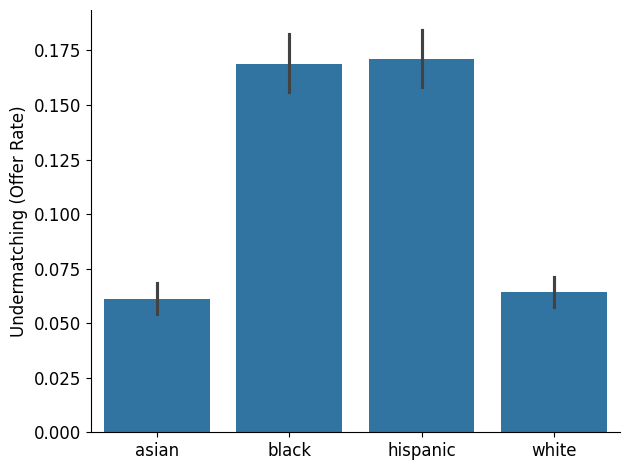

,offer_rate_match,offer_rate_best_cf_pareto,undermatching
count,6000.000000,6000.000000,6000.000000
mean,0.670696,0.554612,0.116084
std,0.318744,0.309163,0.211364
min,0.170940,0.170940,0.000000
25%,0.318266,0.245098,0.000000
50%,0.740903,0.531915,0.000000
75%,1.000000,0.884956,0.131206
max,1.000000,1.000000,0.829060


In [152]:
from plotting_export import create_bar_chart

create_bar_chart(
    df,
    "undermatching",
    title="Undermatching (Offer Rate)",
    do_poverty = False,
    save=False,
)

df[["offer_rate_match", "offer_rate_best_cf_pareto", "undermatching"]].describe()

In [153]:
summary = pd.DataFrame({
    "metric": [
        "mean_offer_rate_match",
        "mean_offer_rate_best_cf",
        "mean_undermatching",
        "mean_undermatching_withinportfolio",
    ],
    "value": [
        df["offer_rate_match"].mean(),
        df["offer_rate_best_cf_pareto"].mean(),
        df["undermatching"].mean(),
        df["undermatching_withinportfolio"].mean(),
    ],
})
summary

,metric,value
0,mean_offer_rate_match,0.670696
1,mean_offer_rate_best_cf,0.554612
2,mean_undermatching,0.116084
3,mean_undermatching_withinportfolio,0.077374


## 7) Offer-rate match by tiebreaker quintile

/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/2122341895.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['tiebreaker_num'] = df['tiebreaker'].apply(tiebreaker_to_num)
/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/2122341895.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['tiebreaker_quintile'] = pd.qcut(df['tiebreaker_num'], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])


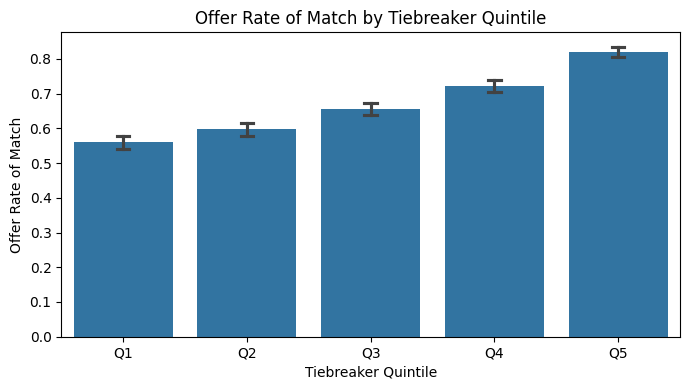

,tiebreaker_quintile,offer_rate_match
0,Q1,0.559187
1,Q2,0.597168
2,Q3,0.655163
3,Q4,0.722600
4,Q5,0.819363


In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

# Build numeric tiebreaker from first 5 hex chars (same convention as project code)
def tiebreaker_to_num(tb):
    if isinstance(tb, str) and len(tb) >= 5:
        return int(format(int(tb[:5], 16), 'd'))
    return np.nan

df['tiebreaker_num'] = df['tiebreaker'].apply(tiebreaker_to_num)

# Quintiles of tiebreaker number
df['tiebreaker_quintile'] = pd.qcut(df['tiebreaker_num'], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])

# Overall by quintile
plt.figure(figsize=(7, 4))
sns.barplot(
    data=df,
    x='tiebreaker_quintile',
    y='offer_rate_match',
    errorbar=('ci', 95),
    capsize=0.1,
    color='#1f77b4',
)
plt.xlabel('Tiebreaker Quintile')
plt.ylabel('Offer Rate of Match')
plt.title('Offer Rate of Match by Tiebreaker Quintile')
plt.tight_layout()
plt.show()

df.groupby('tiebreaker_quintile', observed=False)['offer_rate_match'].mean().reset_index()

## 8) Undermatching by lottery number and by most selective counterfactual

This mirrors the `results_export.ipynb` convention for non-offer-rate metrics:
`undermatching_performance = performance_best_cf_pareto - performance_match`.

/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/2104213863.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['offer_rate_cf_bin'] = df['offer_rate_best_cf_pareto'].apply(lambda x: get_bin(x, bins))


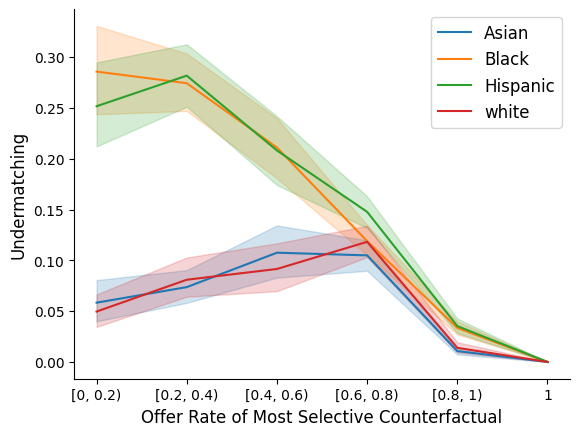

/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/2104213863.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['tiebreaker_bin'] = df['tiebreaker_num'].apply(lambda x: get_bin(x, bins_tiebreaker))


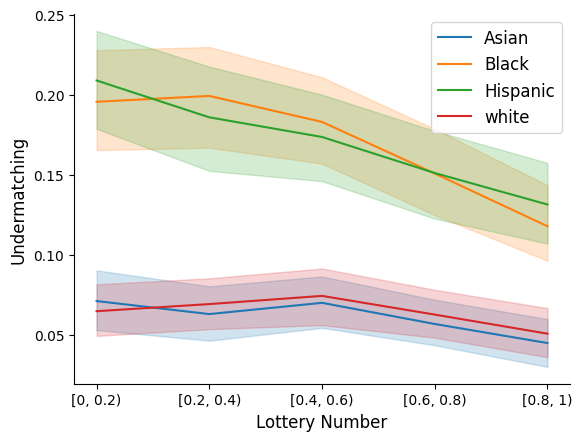

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

def get_bin(offer_rate, bins):
    for i in range(len(bins)-1):
        if offer_rate >= bins[i] and offer_rate < bins[i+1]:
            return i
    
    return len(bins)-2

# ---- Undermatching by student competitiveness (best counterfactual offer rate), by ethnicity ----
bins = [0, 0.2, 0.4, 0.6, 0.8, 1, 100]
df['offer_rate_cf_bin'] = df['offer_rate_best_cf_pareto'].apply(lambda x: get_bin(x, bins))

group_names_pretty = {
        'asian': 'Asian', 'black':'Black', 'hispanic':'Hispanic', 'white':'white',
        'M':'Male',
        'F' : 'Female'
    }

groups = ['asian', 'black', 'hispanic', 'white']
undermatching_values = {}
for group in groups:
    sns.lineplot(x='offer_rate_cf_bin', y='undermatching', data=df[df['ethnicity']==group], label=group_names_pretty[group])

plt.legend(fontsize=12)
plt.xticks(range(len(bins)-1), ['[0, 0.2)', '[0.2, 0.4)', '[0.4, 0.6)', '[0.6, 0.8)', '[0.8, 1)', '1'])
plt.xlabel('Offer Rate of Most Selective Counterfactual', fontsize=12)
plt.ylabel('Undermatching', fontsize=12)
sns.despine()
plt.show()

# ---- Undermatching by lottery number, by ethnicity ----
def get_tiebreaker_num(tiebreaker):
    if type(tiebreaker)==str:
        head = tiebreaker[:5]
        return int(format(int(head, 16), 'd'))/1048518
    else:
        return np.nan

bins_tiebreaker = [0, 0.2, 0.4, 0.6, 0.8, 1]
df['tiebreaker_num'] = df['tiebreaker'].apply(lambda x: get_tiebreaker_num(x))
df['tiebreaker_bin'] = df['tiebreaker_num'].apply(lambda x: get_bin(x, bins_tiebreaker))

undermatching_values = {}
for group in groups:
    sns.lineplot(x='tiebreaker_bin', y=f'undermatching', data=df[df['ethnicity']==group], label=group_names_pretty[group])

plt.legend(fontsize=12)
plt.xticks(range(len(bins_tiebreaker)-1), ['[0, 0.2)', '[0.2, 0.4)', '[0.4, 0.6)', '[0.6, 0.8)', '[0.8, 1)'])
plt.xlabel('Lottery Number', fontsize=12)
plt.ylabel(f'Undermatching', fontsize=12)
sns.despine()
plt.show()

## 8) Optimal recommendation heatmap

Replicates the `results_export.ipynb` heatmap using synthetic portfolios.

/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/3179441387.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['offer_rates'] = df.apply(lambda row: [row[f'offer_rate_{i}'] for i in range(1, 13)], axis=1)
/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/3179441387.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['best_move'] = df['offer_rates'].apply(lambda x: get_best_move(x))
/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/3179441387.py:67: PerformanceWarning: DataFr

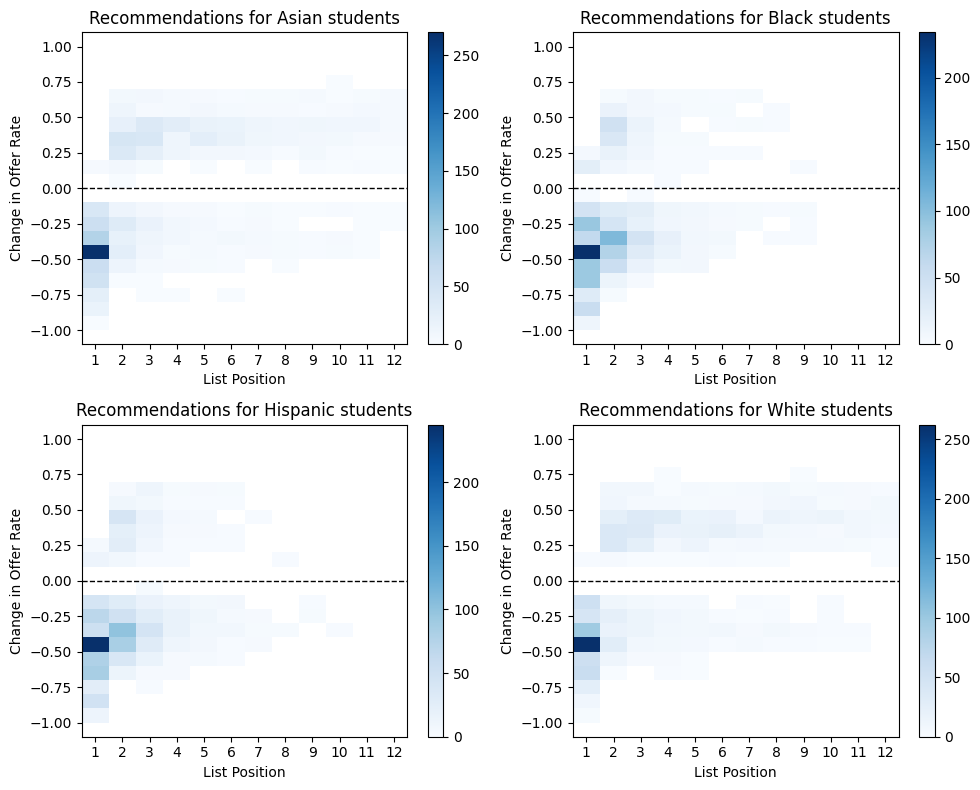

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns


def get_increasing_probs(probs):
    increasing_probs = []
    for i, prob in enumerate(probs):
        if i == 0 or prob > increasing_probs[-1]:
            increasing_probs.append(prob)
    return increasing_probs


def get_score(probs):
    increasing_probs = get_increasing_probs(probs)
    score = 0.0
    low = 0.0
    increasing_probs.append(1.0)
    for prob in increasing_probs:
        score += prob * (prob - low)
        low = prob
    return score


# best way to change the program with a given rank
def get_best_move(probs, candidate_args=False, only_reach=False):
    best_arg = 0
    best_move = 0.0
    best_score = get_score(probs)
    if not candidate_args:
        candidate_args = range(len(probs))

    for arg in candidate_args:
        increasing_probs = []
        increasing_args = []
        for i, prob in enumerate(probs):
            if i == 0 or prob > increasing_probs[-1]:
                increasing_probs.append(prob)
                increasing_args.append(i)

        low_neighbor = 0.0
        i = arg - 1
        while i >= 0:
            if i in increasing_args:
                low_neighbor = probs[i]
                break
            i -= 1

        potential_high_neighbors = get_increasing_probs([low_neighbor, *probs[arg + 1 :]])[1:]
        potential_high_neighbors.append(1.0)
        for high_neighbor in potential_high_neighbors:
            probs_potential = probs.copy()
            probs_potential[arg] = (low_neighbor + high_neighbor) / 2
            score = get_score(probs_potential)
            if score < best_score:
                best_move = (low_neighbor + high_neighbor) / 2 - probs[arg]
                best_score = score
                best_arg = arg

    if only_reach and best_move > 0:
        best_move = 0.0
    return best_arg, best_move


# Build offer-rate vectors and recommendation stats
df['offer_rates'] = df.apply(lambda row: [row[f'offer_rate_{i}'] for i in range(1, 13)], axis=1)
df['best_move'] = df['offer_rates'].apply(lambda x: get_best_move(x))
df['best_move_arg'] = df['best_move'].apply(lambda x: x[0])
df['best_move_offer_rate_change'] = df['best_move'].apply(lambda x: x[1])

groups = ['asian', 'black', 'hispanic', 'white']
group_names_pretty = {'asian': 'Asian', 'black': 'Black', 'hispanic': 'Hispanic', 'white': 'White'}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for i, ax in enumerate(axes):
    sns.histplot(
        x=df[df['ethnicity'] == groups[i]]['best_move_arg'],
        y=df[df['ethnicity'] == groups[i]]['best_move_offer_rate_change'],
        bins=[np.linspace(-0.5, 11.5, 13), np.linspace(-1, 1, 21)],
        ax=ax,
        cbar=True,
        cmap='Blues',
        vmin=0,
    )
    ax.plot([-0.5, 11.5], [0, 0], color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('List Position')
    ax.set_ylabel('Change in Offer Rate')
    ax.set_xlim(-0.5, 11.5)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xticks(range(12), range(1, 13))
    ax.set_title(f"Recommendations for {group_names_pretty[groups[i]]} students")

plt.tight_layout()
plt.show()

## 9) Simulate matching if students adopt the recommended portfolio change

This replicates the recommendation-adoption simulation flow from `results_export.ipynb` for a single-change recommendation.

In [157]:
# Build recommended one-change portfolios (individual-level simulation, as in results notebook)
available_programs_for_sim = sorted({sg.split('-')[0] for sg in seatgroups})
offer_rate_dict = dict(zip(df_programs['programcode'], df_programs['offer_rate']))

# given a list of candidate programs, choose the program with the nearest offer rate to target
def get_program_with_nearest_offer_rate(target_offer_rate, programs, r=RECOMMENDATION_TOP_R):
    programs = [p for p in programs if p in offer_rate_dict]
    if len(programs) == 0:
        return None
    offer_rates = np.array([offer_rate_dict[p] for p in programs])
    i = np.random.randint(np.min([r, len(programs)]))
    arg = np.argsort(np.abs(target_offer_rate - offer_rates))[i]
    return programs[arg]

# given a portfolio, compute the implied match using existing counterfactual offer indicators
def get_match_from_portfolio(row, portfolio):
    close_programs = set(row['close_programs_with_counterfactual'])
    for program in portfolio:
        if pd.isnull(program):
            continue
        if program == row['matched_program']:
            return program
        if (program in close_programs) and bool(row[program]):
            return program
    return np.nan

# return a modified portfolio, changing the program in a given rank
def make_change(portfolio, rank, program):
    portfolio = portfolio.copy()
    if len(portfolio) > 0 and pd.notnull(program):
        portfolio[rank] = program
    return portfolio

df['portfolio'] = df.apply(lambda row: [row[f'programcode{i}'] for i in range(1, 13)], axis=1)
df['candidate_programs'] = df.apply(
    lambda row: [
        prog for prog in row['close_programs_with_counterfactual']
        if prog in available_programs_for_sim and prog not in set([x for x in row['portfolio'] if pd.notnull(x)])
    ],
    axis=1,
)

df['recommended_offer_rate'] = df.apply(
    lambda row: row['offer_rates'][row['best_move_arg']] + row['best_move_offer_rate_change'], axis=1
)
df['recommended_program_one'] = df.apply(
    lambda row: get_program_with_nearest_offer_rate(
        row['recommended_offer_rate'],
        row['candidate_programs'],
        r=RECOMMENDATION_TOP_R,
    ),
    axis=1,
)
df['portfolio_one'] = df.apply(
    lambda row: make_change(row['portfolio'], row['best_move'][0], row['recommended_program_one']), axis=1
)

# Individual (non-equilibrium) simulated matches
df['portfolio_match'] = df.apply(lambda row: get_match_from_portfolio(row, row['portfolio']), axis=1)
df['portfolio_one_match'] = df.apply(lambda row: get_match_from_portfolio(row, row['portfolio_one']), axis=1)

df['portfolio_match_offer_rate'] = df['portfolio_match'].map(offer_rate_dict).fillna(1.0)
df['portfolio_one_match_offer_rate'] = df['portfolio_one_match'].map(offer_rate_dict).fillna(1.0)
df['portfolio_one_match_offer_rate_diff'] = df['portfolio_one_match_offer_rate'] - df['portfolio_match_offer_rate']

print('Baseline consistency check (portfolio_match vs matched_program):',
      (df['portfolio_match'].fillna('no match') == df['matched_program'].fillna('no match')).mean())
print('Mean offer-rate change under one-change recommendation:', df['portfolio_one_match_offer_rate_diff'].mean())
print('Share with improved (lower) offer rate:', (df['portfolio_one_match_offer_rate_diff'] < 0).mean())

df[[
    'matched_program',
    'portfolio_match',
    'portfolio_one_match',
    'portfolio_one_match_offer_rate_diff'
]].head(10)

/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/1207051667.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['portfolio'] = df.apply(lambda row: [row[f'programcode{i}'] for i in range(1, 13)], axis=1)
/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/1207051667.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['candidate_programs'] = df.apply(
/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/1207051667.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is 

Baseline consistency check (portfolio_match vs matched_program): 1.0
Mean offer-rate change under one-change recommendation: -0.027266746634727154
Share with improved (lower) offer rate: 0.17283333333333334


/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/1207051667.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['portfolio_one_match'] = df.apply(lambda row: get_match_from_portfolio(row, row['portfolio_one']), axis=1)
/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/1207051667.py:62: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['portfolio_match_offer_rate'] = df['portfolio_match'].map(offer_rate_dict).fillna(1.0)
/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/1207051667.

,matched_program,portfolio_match,portfolio_one_match,portfolio_one_match_offer_rate_diff
0,Y32B,Y32B,M75A,-0.023304
1,M86A,M86A,M86A,0.000000
2,M17J,M17J,M17J,0.000000
3,X29K,X29K,X29K,0.000000
4,K54A,K54A,Y32B,-0.305556
5,X83X,X83X,X83X,0.000000
6,K64A,K64A,K64A,0.000000
7,R30S,R30S,R30S,0.000000
8,M30B,M30B,M30B,0.000000
9,M35C,M35C,M35C,0.000000


### Recommended portfolio examples (same plot style as `results_export.ipynb`)

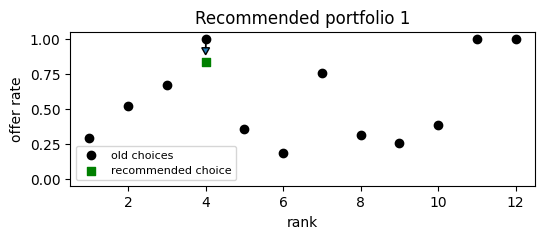

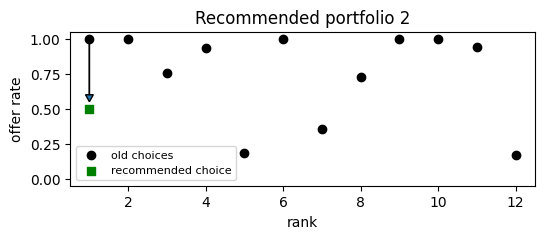

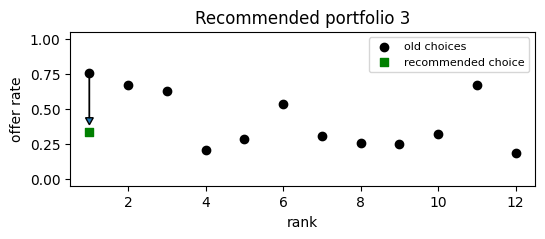

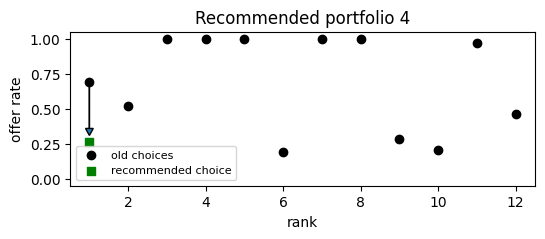

In [158]:
def plot_portfolio_recommendation(row, title='recommended portfolio'):
    offer_rates = row['offer_rates'].to_list()[0]
    best_arg, best_move = row['best_move'].to_list()[0]
    if np.abs(best_move) > 0.1:
        best_move_shortened = -(np.abs(best_move) - 0.1) if best_move < 0 else best_move - 0.1
    else:
        best_move_shortened = 0
    plt.figure(figsize=(6, 2))
    plt.scatter(range(1, len(offer_rates)+1), offer_rates, color='black', label='old choices')
    plt.scatter([best_arg + 1], [offer_rates[best_arg] + best_move], marker='s', color='green', label='recommended choice')
    plt.arrow(best_arg + 1, offer_rates[best_arg], 0, best_move_shortened, head_width=0.2, head_length=0.05)
    plt.xlim(0.5, 12.5)
    plt.ylim(-0.05, 1.05)
    plt.xlabel('rank')
    plt.ylabel('offer rate')
    plt.title(title)
    plt.legend()
    plt.show()

plot_portfolio_recommendation(df.sample(1, random_state=0), title='Recommended portfolio 1')
plot_portfolio_recommendation(df.sample(1, random_state=1), title='Recommended portfolio 2')
plot_portfolio_recommendation(df.sample(1, random_state=2), title='Recommended portfolio 3')
plot_portfolio_recommendation(df.sample(1, random_state=3), title='Recommended portfolio 4')

## 10) Not-matched rate by ethnicity

/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/4033958794.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['not_matched'] = (df['matched'] == 0).astype(int)


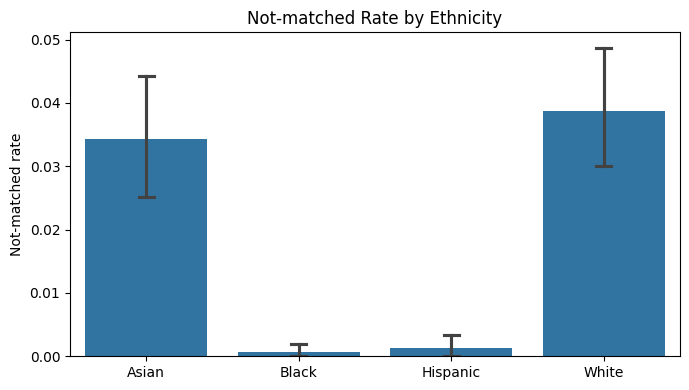

,ethnicity_pretty,not_matched
3,White,0.038692
0,Asian,0.034369
2,Hispanic,0.001364
1,Black,0.000657


In [159]:
import seaborn as sns
import matplotlib.pyplot as plt

# Not matched indicator
if 'not_matched' not in df.columns:
    df['not_matched'] = (df['matched'] == 0).astype(int)

group_names_pretty = {'asian': 'Asian', 'black': 'Black', 'hispanic': 'Hispanic', 'white': 'White'}
plot_df = df[df['ethnicity'].isin(group_names_pretty.keys())].copy()
plot_df['ethnicity_pretty'] = plot_df['ethnicity'].map(group_names_pretty)

plt.figure(figsize=(7, 4))
sns.barplot(
    data=plot_df,
    x='ethnicity_pretty',
    y='not_matched',
    order=['Asian', 'Black', 'Hispanic', 'White'],
    errorbar=('ci', 95),
    capsize=0.1,
    color='#1f77b4',
)
plt.xlabel('')
plt.ylabel('Not-matched rate')
plt.title('Not-matched Rate by Ethnicity')
plt.tight_layout()
plt.show()

plot_df.groupby('ethnicity_pretty')['not_matched'].mean().reset_index().sort_values('not_matched', ascending=False)

## 11) Undermatching level: pre vs post recommendation (individual simulation)

/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/3301636627.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['undermatching_pre_recommendation'] = df['portfolio_match_offer_rate'] - df['offer_rate_best_cf_pareto']
/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/3301636627.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['undermatching_post_recommendation'] = df['portfolio_one_match_offer_rate'] - df['offer_rate_best_cf_pareto']


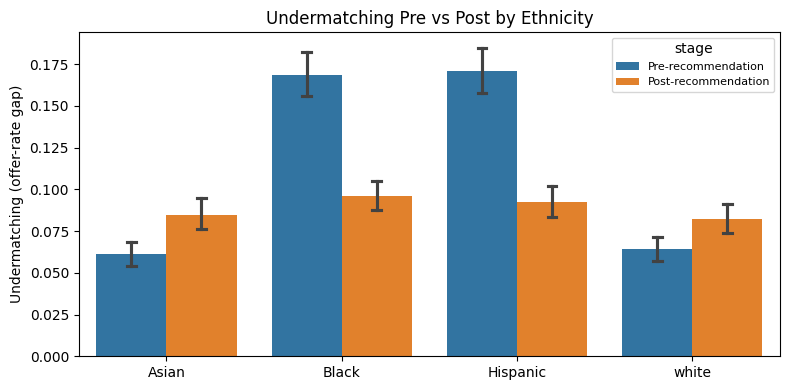

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt

# Individual (non-equilibrium) undermatching before/after recommendation adoption
# Lower offer rate is better, so positive gap means undermatching.
df['undermatching_pre_recommendation'] = df['portfolio_match_offer_rate'] - df['offer_rate_best_cf_pareto']
df['undermatching_post_recommendation'] = df['portfolio_one_match_offer_rate'] - df['offer_rate_best_cf_pareto']

# Demographic breakdown in long format (for seaborn CI computation)
plot_df = df[['ethnicity', 'poverty', 'undermatching_pre_recommendation', 'undermatching_post_recommendation']].copy()
plot_df = plot_df.rename(columns={
    'undermatching_pre_recommendation': 'Pre-recommendation',
    'undermatching_post_recommendation': 'Post-recommendation',
})
long_df = plot_df.melt(
    id_vars=['ethnicity', 'poverty'],
    value_vars=['Pre-recommendation', 'Post-recommendation'],
    var_name='stage',
    value_name='undermatching',
)

group_names_pretty = {'asian': 'Asian', 'black': 'Black', 'hispanic': 'Hispanic', 'white': 'white'}
long_df = long_df[long_df['ethnicity'].isin(group_names_pretty.keys())].copy()
long_df['ethnicity'] = long_df['ethnicity'].map(group_names_pretty)
long_df['FRL'] = long_df['poverty'].map({0: 'False', 1: 'True'})

# By ethnicity (with 95% CI, seaborn-style)
plt.figure(figsize=(8, 4))
sns.barplot(
    data=long_df,
    x='ethnicity',
    y='undermatching',
    hue='stage',
    order=['Asian', 'Black', 'Hispanic', 'white'],
    errorbar=('ci', 95),
    capsize=0.1,
)
plt.ylabel('Undermatching (offer-rate gap)')
plt.xlabel('')
plt.title('Undermatching Pre vs Post by Ethnicity')
plt.tight_layout()
plt.show()

## 12) Equilibrium undermatching pre vs post recommendation

102


/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/2779823637.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_local[outcome_col] = [seatgroup_to_program_dict[seatgroups[i]] if i >= 0 else np.nan for i in student_matches]


66


/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/2779823637.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['equilibrium_offer_rate_original'] = df['equilibrium_match_original'].map(offer_rate_dict).fillna(1.0)
/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/2779823637.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['equilibrium_offer_rate_one'] = df['equilibrium_match_one'].map(offer_rate_dict).fillna(1.0)
/var/folders/1j/2gvg09j94934mlz9v609tcvh0000gn/T/ipykernel_57375/277982363

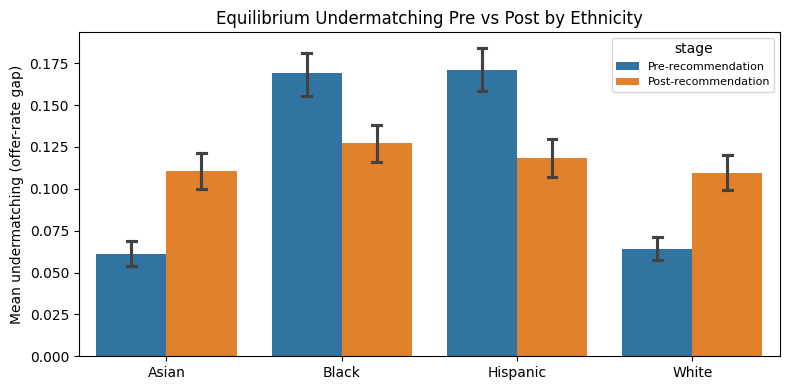

,ethnicity,stage,equilibrium_undermatching
0,Asian,Post-recommendation,0.110558
1,Asian,Pre-recommendation,0.061123
2,Black,Post-recommendation,0.127066
3,Black,Pre-recommendation,0.168820
4,Hispanic,Post-recommendation,0.118573
5,Hispanic,Pre-recommendation,0.171060
6,White,Post-recommendation,0.109553
7,White,Pre-recommendation,0.064248


In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert program portfolios to seatgroup preference args
seatgroup_arg_dict = {sg: i for i, sg in enumerate(seatgroups)}
seatgroup_to_program_dict = {sg: sg.split('-')[0] for sg in seatgroups}
num_seat_groups_dict = {
    p: len([sg for sg in seatgroups if sg.split('-')[0] == p])
    for p in set(seatgroup_to_program_dict.values())
}

def programs_to_seatgroup_args(programs):
    sgs = []
    for programcode in programs:
        if pd.notnull(programcode) and programcode in num_seat_groups_dict:
            for i in range(num_seat_groups_dict[programcode]):
                sgs.append(f'{programcode}-{i}')
    return [seatgroup_arg_dict[sg] for sg in sgs]

def add_predicted_equilibrium_match(df_local, student_prefs, seatgroup_prefs, seatgroup_caps, outcome_col):
    student_matches, _ = da.get_match(student_prefs, seatgroup_prefs, seatgroup_caps)
    df_local[outcome_col] = [seatgroup_to_program_dict[seatgroups[i]] if i >= 0 else np.nan for i in student_matches]

# Ensure portfolios exist
if 'portfolio' not in df.columns:
    df['portfolio'] = df.apply(lambda row: [row[f'programcode{i}'] for i in range(1, 13)], axis=1)
if 'portfolio_one' not in df.columns:
    raise ValueError('portfolio_one not found. Run Section 8 first.')

student_prefs_original = [programs_to_seatgroup_args(p) for p in df['portfolio'].to_list()]
student_prefs_one = [programs_to_seatgroup_args(p) for p in df['portfolio_one'].to_list()]

add_predicted_equilibrium_match(df, student_prefs_original, college_prefs, college_caps, 'equilibrium_match_original')
add_predicted_equilibrium_match(df, student_prefs_one, college_prefs, college_caps, 'equilibrium_match_one')

df['equilibrium_offer_rate_original'] = df['equilibrium_match_original'].map(offer_rate_dict).fillna(1.0)
df['equilibrium_offer_rate_one'] = df['equilibrium_match_one'].map(offer_rate_dict).fillna(1.0)

# Equilibrium undermatching (positive => worse than best counterfactual)
df['equilibrium_undermatching_pre'] = df['equilibrium_offer_rate_original'] - df['offer_rate_best_cf_pareto']
df['equilibrium_undermatching_post'] = df['equilibrium_offer_rate_one'] - df['offer_rate_best_cf_pareto']

# Ethnicity-only breakdown (no aggregate plot)
eq_plot_df = df[['ethnicity', 'equilibrium_undermatching_pre', 'equilibrium_undermatching_post']].copy()
eq_plot_df = eq_plot_df.rename(columns={
    'equilibrium_undermatching_pre': 'Pre-recommendation',
    'equilibrium_undermatching_post': 'Post-recommendation',
})
eq_long_df = eq_plot_df.melt(
    id_vars=['ethnicity'],
    value_vars=['Pre-recommendation', 'Post-recommendation'],
    var_name='stage',
    value_name='equilibrium_undermatching',
)

group_names_pretty = {'asian': 'Asian', 'black': 'Black', 'hispanic': 'Hispanic', 'white': 'White'}
eq_long_df = eq_long_df[eq_long_df['ethnicity'].isin(group_names_pretty.keys())].copy()
eq_long_df['ethnicity'] = eq_long_df['ethnicity'].map(group_names_pretty)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=eq_long_df,
    x='ethnicity',
    y='equilibrium_undermatching',
    hue='stage',
    order=['Asian', 'Black', 'Hispanic', 'White'],
    errorbar=('ci', 95),
    capsize=0.1,
)
plt.xlabel('')
plt.ylabel('Mean undermatching (offer-rate gap)')
plt.title('Equilibrium Undermatching Pre vs Post by Ethnicity')
plt.tight_layout()
plt.show()

eq_long_df.groupby(['ethnicity', 'stage'])['equilibrium_undermatching'].mean().reset_index()

## 13) Matching and undermatching by ZIP code

Using shapefile: ./nyc_zctas.shp


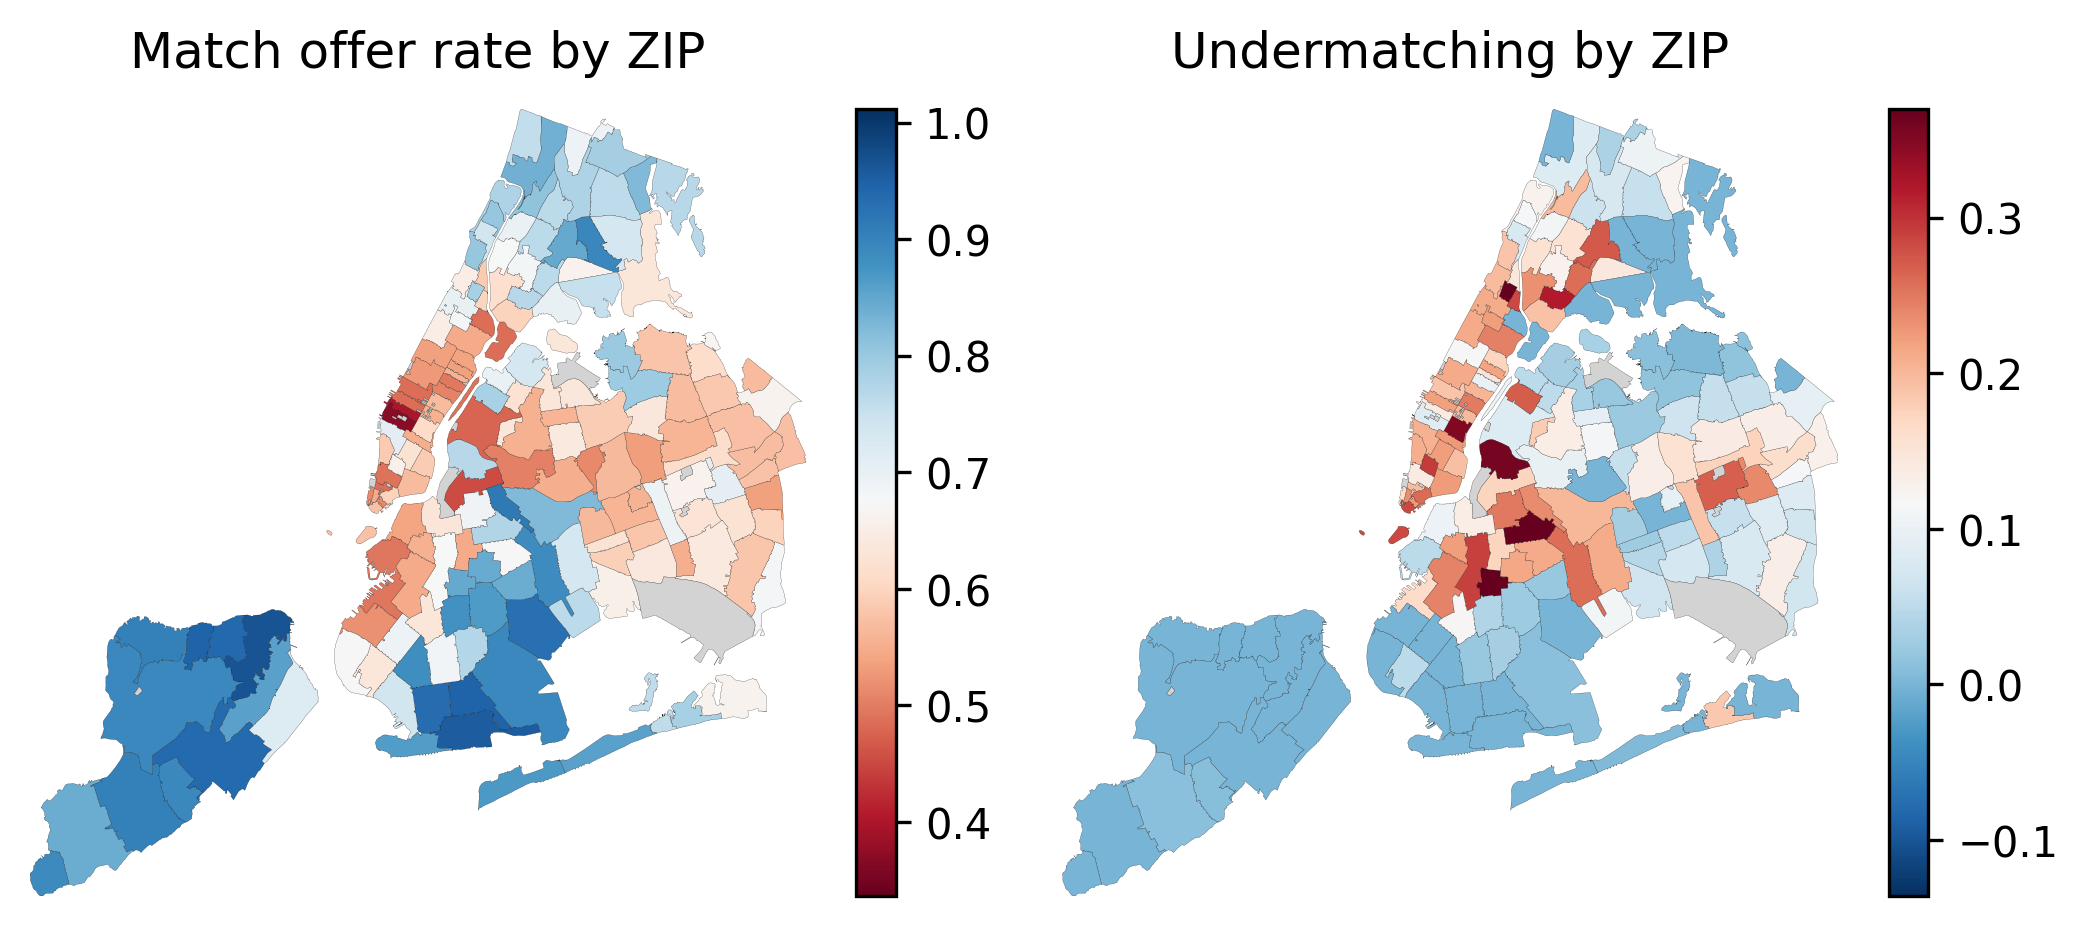

,zipcode,n_students,offer_rate_match,undermatching
124,11239,46,0.765677,0.110690
6,10007,45,0.485664,0.194131
26,10029,45,0.546254,0.244138
76,10472,45,0.660817,0.143706
54,10314,45,0.891421,0.000000
27,10030,45,0.786354,0.388843
125,11354,44,0.797698,0.015688
4,10005,44,0.510947,0.224583
28,10031,43,0.650365,0.196610
86,11105,43,0.732819,0.030593


In [162]:
import os
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Allow GDAL to recreate missing .shx sidecar files when opening .shp
os.environ.setdefault('SHAPE_RESTORE_SHX', 'YES')

# Optional basemap support (used in plot_maps.ipynb)
try:
    import contextily as ctx
    HAS_CONTEXTILY = True
except Exception:
    HAS_CONTEXTILY = False

# Aggregate student outcomes to ZIP level
MIN_STUDENTS_PER_ZIP = 10

df_zip = (
    df.assign(zipcode=df['zipcode'].astype(str).str.extract(r'(\d{5})', expand=False))
      .dropna(subset=['zipcode'])
      .groupby('zipcode', as_index=False)
      .agg(
          n_students=('student_id_scram', 'count'),
          offer_rate_match=('offer_rate_match', 'mean'),
          undermatching=('undermatching', 'mean'),
      )
)

df_zip = df_zip[df_zip['n_students'] >= MIN_STUDENTS_PER_ZIP].copy()

# NYC-only shapefile candidate (matches plot_maps.ipynb scope).
SHAPEFILE_CANDIDATES = [
    './nyc_zctas.shp',
]

def plot_two_cols_zip(df_zip, col1, col2, title1, title2, std1range=2.5, std2range=2.5, title='matching_undermatching', reverse_first_colors=False):
    # Set font sizes for scientific publication (matching plot_maps.ipynb style)
    plt.rcParams.update({
        'font.size': 10,
        'axes.titlesize': 12,
        'axes.labelsize': 10,
        'legend.fontsize': 8,
    })

    # Read and prepare data (attempt SHX restoration if index sidecar is missing)
    shapefile_used = SHAPEFILE_CANDIDATES[0]
    gdf = gpd.read_file(shapefile_used)

    # Use the exact ZIP column used in plot_maps.ipynb
    zcta_col = 'ZCTA5CE20'
    if zcta_col not in gdf.columns:
        raise ValueError(
            f"Expected '{zcta_col}' in {shapefile_used}, but found columns: {list(gdf.columns)}"
        )

    print('Using shapefile:', shapefile_used)

    gdf[zcta_col] = gdf[zcta_col].astype(str)
    df_local = df_zip.copy()
    df_local['zipcode'] = df_local['zipcode'].astype(str)

    # Match plot_maps projection behavior
    gdf = gdf.to_crs(epsg=3857)

    # Merge data
    gdf = gdf.merge(df_local, left_on=zcta_col, right_on='zipcode', how='left')

    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3.5), dpi=300)
    fig.patch.set_facecolor('white')

    # Center colormaps around sample means
    mean_val1 = gdf[col1].mean()
    std_val1 = gdf[col1].std()
    norm1 = colors.TwoSlopeNorm(
        vmin=mean_val1 - std1range * std_val1,
        vcenter=mean_val1,
        vmax=mean_val1 + std1range * std_val1,
    )

    mean_val2 = gdf[col2].mean()
    std_val2 = gdf[col2].std()
    norm2 = colors.TwoSlopeNorm(
        vmin=mean_val2 - std2range * std_val2,
        vcenter=mean_val2,
        vmax=mean_val2 + std2range * std_val2,
    )

    ax1.set_facecolor('white')
    ax2.set_facecolor('white')

    # First map
    first_cmap = 'RdBu_r'
    if reverse_first_colors:
        first_cmap = 'RdBu'

    gdf.plot(
        column=col1,
        ax=ax1,
        legend=True,
        cmap=first_cmap,
        norm=norm1,
        edgecolor='black',
        linewidth=0.05,
        missing_kwds={'color': 'lightgrey'},
    )

    # Second map
    gdf.plot(
        column=col2,
        ax=ax2,
        legend=True,
        cmap='RdBu_r',
        norm=norm2,
        edgecolor='black',
        linewidth=0.05,
        missing_kwds={'color': 'lightgrey'},
    )

    if HAS_CONTEXTILY:
        carto_light = ctx.providers.CartoDB.PositronNoLabels
        ctx.add_basemap(ax1, source=carto_light, alpha=0.3)
        ctx.add_basemap(ax2, source=carto_light, alpha=0.3)

    for txt in ax1.texts:
        txt.remove()
    for txt in ax2.texts:
        txt.remove()

    for ax, ttl in [(ax1, title1), (ax2, title2)]:
        ax.set_title(ttl, pad=10, y=1.0)
        ax.axis('off')
        bounds = gdf.total_bounds
        ax.set_xlim(bounds[0], bounds[2])
        ax.set_ylim(bounds[1], bounds[3])

    plt.tight_layout(pad=0.01)
    plt.subplots_adjust(top=0.75)
    plt.show()

plot_two_cols_zip(
    df_zip,
    col1='offer_rate_match',
    col2='undermatching',
    title1='Match offer rate by ZIP',
    title2='Undermatching by ZIP',
    reverse_first_colors=True,
)

df_zip.sort_values('n_students', ascending=False).head(10)